# Problem 1

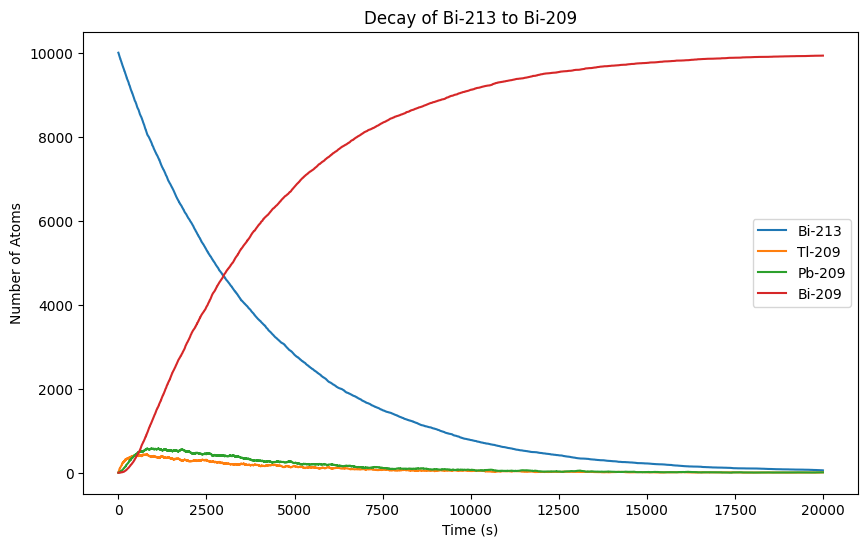

In [11]:
from random import random
import numpy as np
import matplotlib.pyplot as plt

tau_Bi213 = 46*60
tau_Tl209 = 2.2*60
tau_Pb209 = 3.3*60  
h = 1
p_Bi = 1 - 2**(-h/tau_Bi213)
p_Tl = 1 - 2**(-h/tau_Tl209)
p_Pb = 1 - 2**(-h/tau_Pb209)
tmax = 20000
tpoints = np.arange(0.0, tmax, h)
Bi213_points = []
Tl_points = []  
Pb_points = []
Bi209_points = []   
Bi213 = 10000   
Tl209 = 0
Pb209 = 0
Bi209 = 0
for t in tpoints:
    for i in range(Pb209):       # Part (a)
        if random() < p_Pb:
            Pb209 -= 1
            Bi209 += 1  
    for i in range(Tl209):       # Part (b)
        if random() < p_Tl:
            Tl209 -= 1
            Pb209 += 1
    for i in range(Bi213):       # Part (c)
        if random() < p_Bi:
            Bi213 -= 1
            if random() < 0.9791:
                Tl209 += 1
            else:
                Pb209 += 1    
    Pb_points.append(Pb209)
    Bi209_points.append(Bi209)
    Tl_points.append(Tl209)
    Bi213_points.append(Bi213)


plt.figure(figsize=(10,6))
plt.plot(tpoints, Bi213_points, label='Bi-213')
plt.plot(tpoints, Tl_points, label='Tl-209')
plt.plot(tpoints, Pb_points, label='Pb-209')
plt.plot(tpoints, Bi209_points, label='Bi-209')
plt.xlabel('Time (s)')
plt.ylabel('Number of Atoms')
plt.title('Decay of Bi-213 to Bi-209')
plt.legend()
plt.show()


# Problem 2

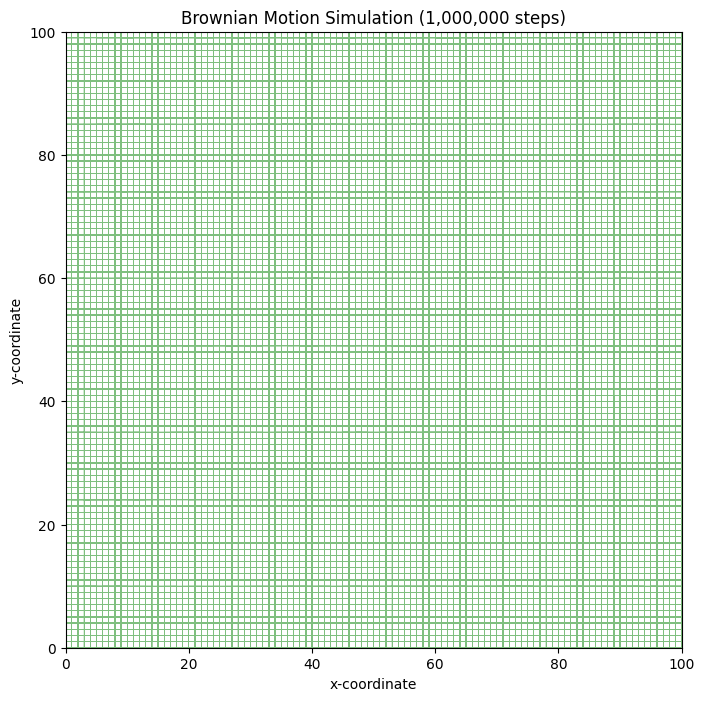

In [12]:
def simulate_brownian_motion(L=101, num_steps=1000000):
    x = np.zeros(num_steps, dtype=int)
    y = np.zeros(num_steps, dtype=int)
    x[0] = L // 2
    y[0] = L // 2
    directions = np.array([[1,0], [-1,0], [0,1], [0,-1]])

    for i in range(1, num_steps):
        current_x = x[i-1]
        current_y = y[i-1]
        valid_move = False
        while not valid_move:
            dx, dy = directions[np.random.randint(4)]
            next_x = current_x + dx
            next_y = current_y + dy
            if 0 <= next_x < L and 0 <= next_y < L:
                x[i] = next_x
                y[i] = next_y
                valid_move = True
    return x, y

L = 101
num_steps = 1000000
x_path, y_path = simulate_brownian_motion(L, num_steps)
plt.figure(figsize=(8, 8))
plt.plot(x_path, y_path, linewidth=0.2, color='green', alpha=0.5)
plt.title(f"Brownian Motion Simulation ({num_steps:,} steps)")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.xlim(0, L - 1)
plt.ylim(0, L - 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(False)
plt.show()


# Problem 3

3a

In [13]:
def f(x):
    y = 1/(x*(x-2))
    z = np.floor(y)
    return np.sin(z)**2
N = 10000
k = 0
for i in range(N):
    x = 2*random()
    if random() < f(x):
        k += 1
I = 2*k/N
print(f'Integral is {I}')
error = np.sqrt(I*(2-I)/N)
print(f'Error is {error}')

Integral is 1.3726
Error is 0.009279920473797176


3b

In [14]:
def f(x):
    y = 1/(x*(x-2))
    z = np.floor(y)
    return np.sin(z)**2

x = np.random.uniform(0, 2, N)
y = f(x)
sum = np.sum(y)
I = 2*sum/N
print(f'Integral is {I}')
sum2 = np.sum(y**2)
error = 2*np.sqrt((sum2/N - (sum/N)**2)/N)
print(f'Error is {error}')

Integral is 1.3754269996531587
Error is 0.005805976696786917


# Problem 4

In [15]:
N =10000
n = 10
k = 0
for i in range(N):
    x = np.random.uniform(-1, 1, n)
    if np.linalg.norm(x) < 1:
        k += 1
V = 2**n * k/N
print(f'Volume is {V}')


Volume is 3.1744


# Problem 5

## 5a

$$w(x) = x^{-1/2} = \frac{1}{\sqrt{x}}$$

$$p(x) \propto w(x) = \frac{1}{\sqrt{x}}$$
As, $$\int_0^1 p(x)\,dx = 1$$
So:
$$p(x) = \frac{w(x)}{\int_0^1 w(x)\,dx} = \frac{1/\sqrt{x}}{\int_0^1 \frac{1}{\sqrt{x}}\,dx}$$

$$\int_0^1 \frac{1}{\sqrt{x}}\,dx = \int_0^1 x^{-1/2}\,dx = \left[2\sqrt{x}\right]_0^1 = 2$$

Therefore:

$$p(x) = \frac{1/\sqrt{x}}{2} = \frac{1}{2\sqrt{x}}$$

Since $z \sim \text{Uniform}[0,1]$, we have $q(z) = 1$.

Using $p(x)dx = q(z)dz$:

$$z = \int_0^x p(t)\,dt = \int_0^x \frac{1}{2\sqrt{t}}\,dt = \left[\sqrt{t}\right]_0^x = \sqrt{x}$$

Inverting this relationship:
$$x = z^2$$


In [16]:
import numpy as np
N =10000000

z = np.random.uniform(0, 1, N)
def g(z):
    return z*z
x = g(z)
def m(x):
    return 1/(np.exp(x)+1)
y = m(x)
sum = np.sum(y)
I = 2* sum/N
print(f'Integral is {I}')


Integral is 0.8389197290396642


# Problem 6

6a

In [17]:
# We will impose periodic boundary conditions for simplicity
N = 20
def energy(system, J = 1):
    E = 0
    for i in range(N):
        for j in range(N):
            s = system[i,j]
            E -= s * (system[(i+1)%N, j] + system[i, (j+1)%N])
    return -J*E/2


6b

In [18]:
kB = 1
T = 1

system = np.random.choice([-1, 1], size=(20, 20))
E = energy(system)
print(f'Initial energy: {E}')

for step in range(100000):
    i, j = np.random.randint(0, 20, size=2)
    s = system[i, j]
    neighbors = [system[(i+1)%20, j], system[(i-1)%20, j], system[i, (j+1)%20], system[i, (j-1)%20]]
    dE = 2 * s * np.sum(neighbors) # Energy change if we flip this spin
    if dE < 0 or random() < np.exp(-dE/(kB*T)):
        system[i, j] *= -1  # Flip the spin
E_final = energy(system)
print(f'Final energy: {E_final}')


Initial energy: 8.0
Final energy: 350.0


6c

Initial energy: -10.0
Final energy: 400.0


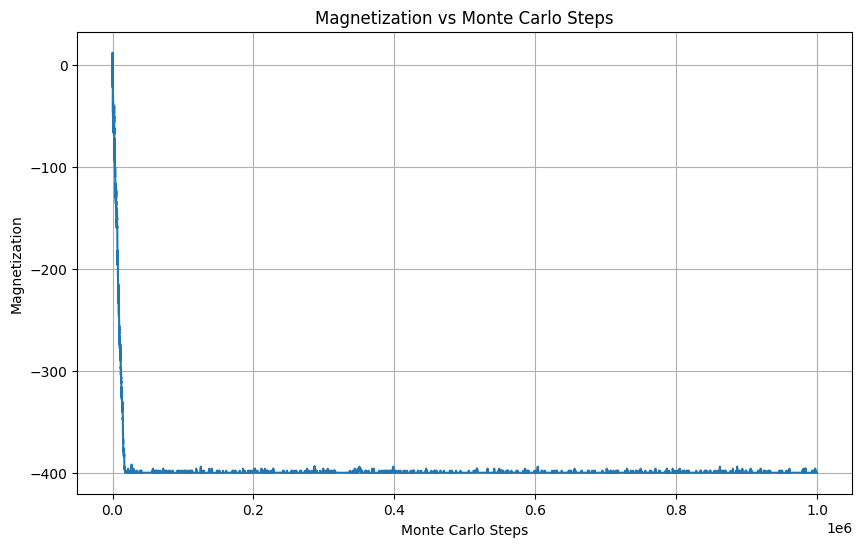

In [19]:
kB = 1
T = 1

system = np.random.choice([-1, 1], size=(20, 20))
E = energy(system)
print(f'Initial energy: {E}')
M = [np.sum(system)]
for step in range(1000000):
    i, j = np.random.randint(0, 20, size=2)
    s = system[i, j]
    neighbors = [system[(i+1)%20, j], system[(i-1)%20, j], system[i, (j+1)%20], system[i, (j-1)%20]]
    dE = 2 * s * np.sum(neighbors) 
    if dE < 0 or random() < np.exp(-dE/(kB*T)):
        system[i, j] *= -1  
    M.append(np.sum(system))  
E_final = energy(system)
print(f'Final energy: {E_final}')
plt.figure(figsize=(10, 6))
plt.plot(M)
plt.xlabel('Monte Carlo Steps')
plt.ylabel('Magnetization')
plt.title('Magnetization vs Monte Carlo Steps')
plt.grid()
plt.show()


The system develops spontaneous magnetization because T = 1 is below the critical temperature Tc ≈ 2.27, where the Ising model exhibits a ferromagnetic phase.

6d

In [22]:
kB = 1
T = 1
Final_Magnetizations = []
Final_Energies = []
for k in range(5):
    system = np.random.choice([-1, 1], size=(20, 20))
    E = energy(system)
    M = [np.sum(system)]
    for step in range(1000000):
        i, j = np.random.randint(0, 20, size=2)
        s = system[i, j]
        neighbors = [system[(i+1)%20, j], system[(i-1)%20, j], system[i, (j+1)%20], system[i, (j-1)%20]]
        dE = 2 * s * np.sum(neighbors) 
        if dE < 0 or random() < np.exp(-dE/(kB*T)):
            system[i, j] *= -1  
        M.append(np.sum(system))  
    E_final = energy(system)
    Final_Magnetizations.append(M[-1])
    Final_Energies.append(E_final)
print(f'Final Magnetizations: {Final_Magnetizations}')
print(f'Final Energies: {Final_Energies}')


Final Magnetizations: [np.int64(-400), np.int64(-400), np.int64(-398), np.int64(-400), np.int64(400)]
Final Energies: [np.float64(400.0), np.float64(400.0), np.float64(396.0), np.float64(400.0), np.float64(400.0)]


The sign of magnetization varies between runs because the Hamiltonian is symmetric under spin inversion. The system randomly selects one of the two degenerate ground states, demonstrating spontaneous symmetry breaking.

6e

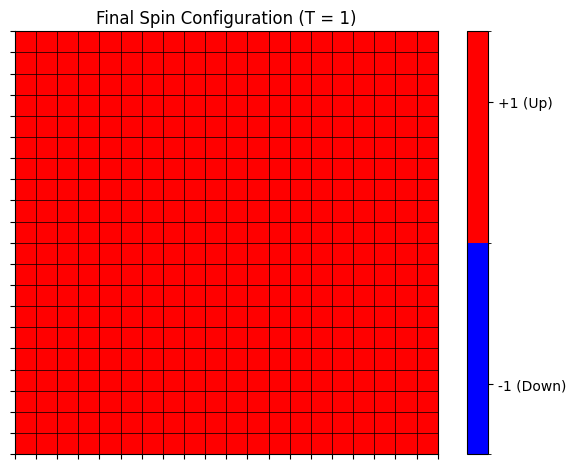

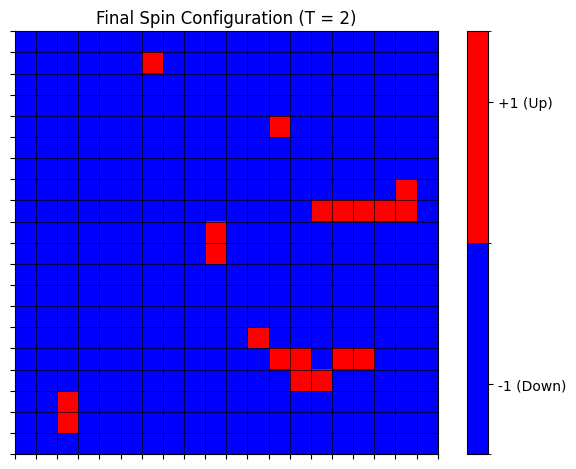

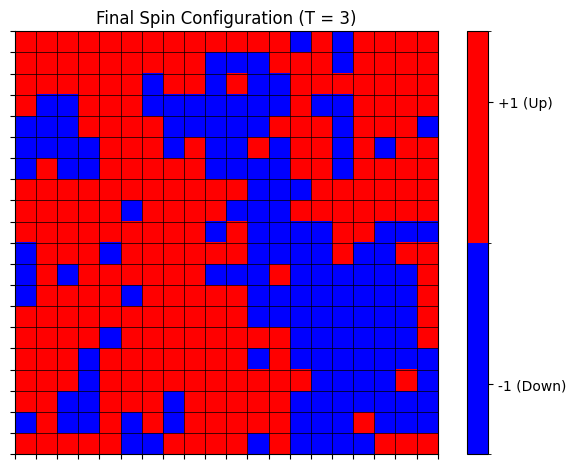

In [23]:
kB = 1
Temp = [1, 2, 3]
for T in Temp:
    system = np.random.choice([-1, 1], size=(20, 20))
    for step in range(1000000):
        i, j = np.random.randint(0, 20, size=2)
        s = system[i, j]
        neighbors = [system[(i+1)%20, j], system[(i-1)%20, j], system[i, (j+1)%20], system[i, (j-1)%20]]
        dE = 2 * s * np.sum(neighbors) 
        if dE < 0 or random() < np.exp(-dE/(kB*T)):
            system[i, j] *= -1  

    N = 20

    plt.figure()
    import matplotlib.colors as mcolors
    cmap = mcolors.ListedColormap(['blue', 'red'])
    bounds = [-1.5, 0, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    plt.imshow(system, cmap=cmap, norm=norm, interpolation='nearest')
    plt.xticks(np.arange(-0.5, N, 1), [])
    plt.yticks(np.arange(-0.5, N, 1), [])
    plt.grid(color='black', linestyle='-', linewidth=0.5)
    plt.xlim(-0.5, N - 0.5)
    plt.ylim(N - 0.5, -0.5)
    cbar = plt.colorbar(ticks=[-1, 1])
    cbar.ax.set_yticklabels(['-1 (Down)', '+1 (Up)'])
    plt.title(f'Final Spin Configuration (T = {T})')
    plt.tight_layout()
    plt.show()

As temperature increases, thermal fluctuations compete with interaction energy. At low temperature, spins align to minimize energy, while at higher temperature entropy dominates, leading to disorder. Around T ≈ 2–3, the system transitions from ordered to disordered behavior.

# Problem 7

7a

Minima as -1.0334199532049737e-05


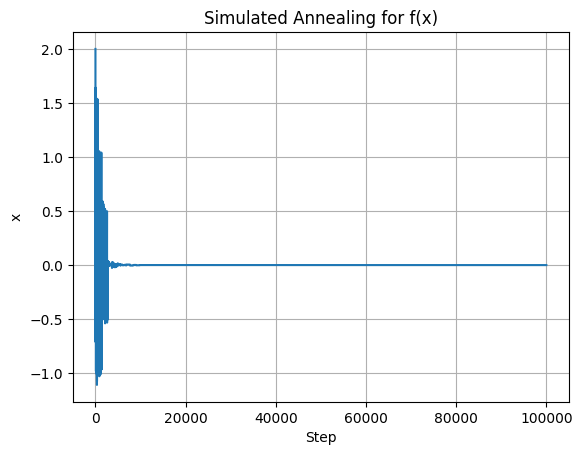

In [24]:
def f(x):
    return x*x - np.cos(4*np.pi*x)

x = 2
N = 100000
xs = []

for t in range(N):
    T = 1.0 * np.exp(-t/1000)  
    delta = np.random.normal(0, 1)
    x_new = x + delta
    dE = f(x_new) - f(x)
    if dE < 0 or np.random.rand() < np.exp(-dE / T):
        x = x_new
    xs.append(x)
print(f'Minima as {np.average(xs[-10000:])}')
plt.figure()
plt.plot(xs)
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Simulated Annealing for f(x)")
plt.grid()
plt.show()


7b

15.95962481068863
15.959423584483202
15.959582548501801
15.959416016776403
15.959316149366522
Minima at x = 15.959472621963311


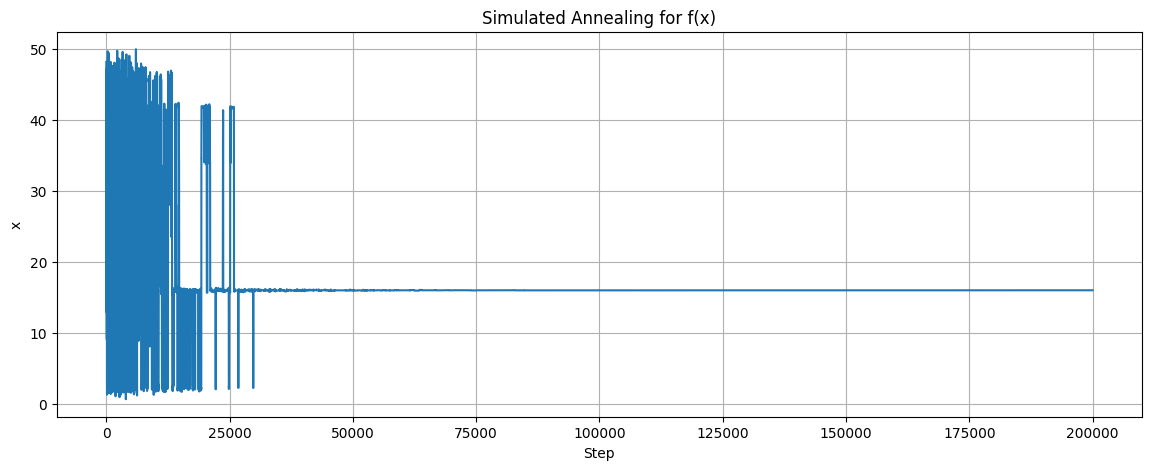

In [25]:
def f(x):
    if x<50 and x>0:
        return np.cos(x)+ np.cos(np.sqrt(2)*x) + np.cos(np.sqrt(3)*x)
    else:
        return float('inf')

N = 200000
out = []
for k in range(5):
    x = np.random.uniform(0, 50)
    xs= []
    for t in range(N):
        T = 1 * np.exp(-20*t/N)  
        delta = np.random.normal(0, 10)
        x_new = x + delta
        dE = f(x_new) - f(x)
        if dE < 0 or np.random.rand() < np.exp(-dE / T):
            x = x_new
        xs.append(x)
    print(np.average(xs[-1000:]))
    out.append(np.average(xs[-1000:]))

print('Minima at x =', np.average(out))
plt.figure(figsize=(14,5))
plt.plot(xs)
plt.xlabel("Step")
plt.ylabel("x")
plt.title("Simulated Annealing for f(x)")
plt.grid()
plt.show()


# Problem 8

## 8a

Ranges-
$$0 \le \theta \le \pi, \quad 0 \le \phi < 2\pi$$
Now,
$$p(\theta,\phi)\,d\theta d\phi = \frac{\sin\theta}{4\pi}\, d\theta d\phi$$
So,
$$p(\theta,\phi) = p(\theta)\,p(\phi)$$
$$p(\theta) = \frac{\sin\theta}{2}, \quad p(\phi) = \frac{1}{2\pi}$$
Normalization:
$$\int_0^{2\pi} p(\phi)\,d\phi = \int_0^{2\pi} \frac{1}{2\pi} d\phi = 1$$
$$\int_0^\pi p(\theta)\,d\theta = \int_0^\pi \frac{\sin\theta}{2} d\theta = \frac{1}{2}[-\cos\theta]_0^\pi = 1$$


## 8b

For $\phi$:

$$\phi = 2\pi u, \quad u \sim \text{Uniform}(0,1)$$

For $\theta$ (Just as done in Problem 5):

$$z = \int_0^\theta p(t)\,dt = \int_0^\theta \frac{\sin t}{2}\,dt = \frac{1}{2}(1 - \cos\theta)$$

Since $z \sim \text{Uniform}(0,1)$:

$$z = \frac{1}{2}(1 - \cos\theta)$$

$$\cos\theta = 1 - 2z$$

$$\theta = \cos^{-1}(1 - 2z)$$

In [26]:
u1 = np.random.uniform(0, 1)
u2 = np.random.uniform(0, 1)
phi = 2 * np.pi * u1
theta = np.arccos(1 - 2 * u2)

print(f'Random point on sphere: (theta={theta:.3f}, phi={phi:.3f})')

Random point on sphere: (theta=1.812, phi=2.040)
